In [40]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
import sys
import glob
from model.data.load_data import *


In [53]:
domain = "NORTHAFRICA"
date = "201407"

In [54]:
fp_datadir = f"/group/chemistry/acrg/LPDM/fp_NAME_pre20210701/{domain}/LMP-10magl_{domain}_{date}.nc"
met_datadir = f"/group/chemistry/acrg/met_archive/UM/{domain}/{domain}_Met_{date}.nc"

# Load the data
fp_ds = xr.open_dataset(fp_datadir)
met_ds = xr.open_dataset(met_datadir)

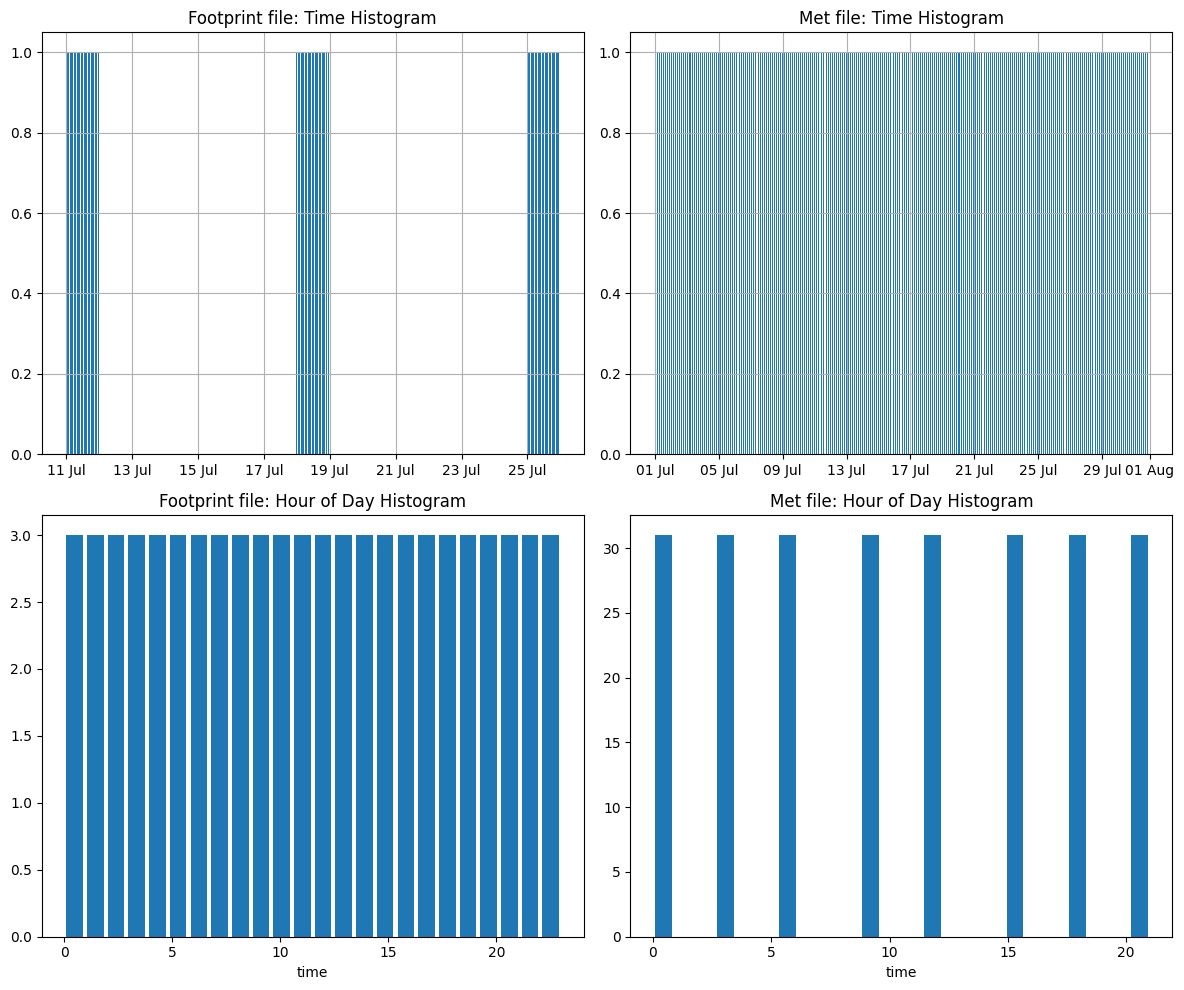

In [55]:
# Visualise fp and met datasets

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
# Example plots using ds and fp_ds time histograms
fp_ds['time'].to_dataframe().hist(column='time',bins=500, ax=axs[0, 0])
axs[0, 0].set_title('Footprint file: Time Histogram')

met_ds['time'].to_dataframe().hist(column='time', bins=500, ax=axs[0, 1])
axs[0, 1].set_title('Met file: Time Histogram')

fp_ds['time'].dt.hour.plot.hist(bins=24, rwidth=0.8, ax=axs[1, 0])
axs[1, 0].set_title('Footprint file: Hour of Day Histogram')

met_ds['time'].dt.hour.plot.hist(bins=24, rwidth=0.8, ax=axs[1, 1])
axs[1, 1].set_title('Met file: Hour of Day Histogram')

date_formatter = mdates.DateFormatter('%d %b')  # Shows e.g. "23 May"
axs[0, 0].xaxis.set_major_formatter(date_formatter)
axs[0, 1].xaxis.set_major_formatter(date_formatter)
plt.tight_layout()
plt.show()

In [ ]:
def interpolate_met_time(ds, interval_minutes=60):
    """
    Interpolate the time dimension of a met xarray.Dataset to a regular interval.

    Parameters
    ----------
    ds : xarray.Dataset
        The meteorological dataset with a 'time' coordinate.
    interval_minutes : int
        Desired interval in minutes for interpolation.

    Returns
    -------
    xarray.Dataset
        Dataset interpolated to the new time grid.
    """
    # Create new time index at desired interval
    time_min = ds['time'].values[0]
    time_max = ds['time'].values[-1]
    new_time = pd.date_range(start=time_min, end=time_max, freq=f'{interval_minutes}T')

    # Interpolate all variables along the time dimension
    ds_interp = ds.interp(time=new_time)
    return ds_interp

In [ ]:
met_interp = interpolate_met_time(met_ds, interval_minutes=15)

/tmp/ipykernel_3350701/2575568210.py:20: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  new_time = pd.date_range(start=time_min, end=time_max, freq=f'{interval_minutes}T')


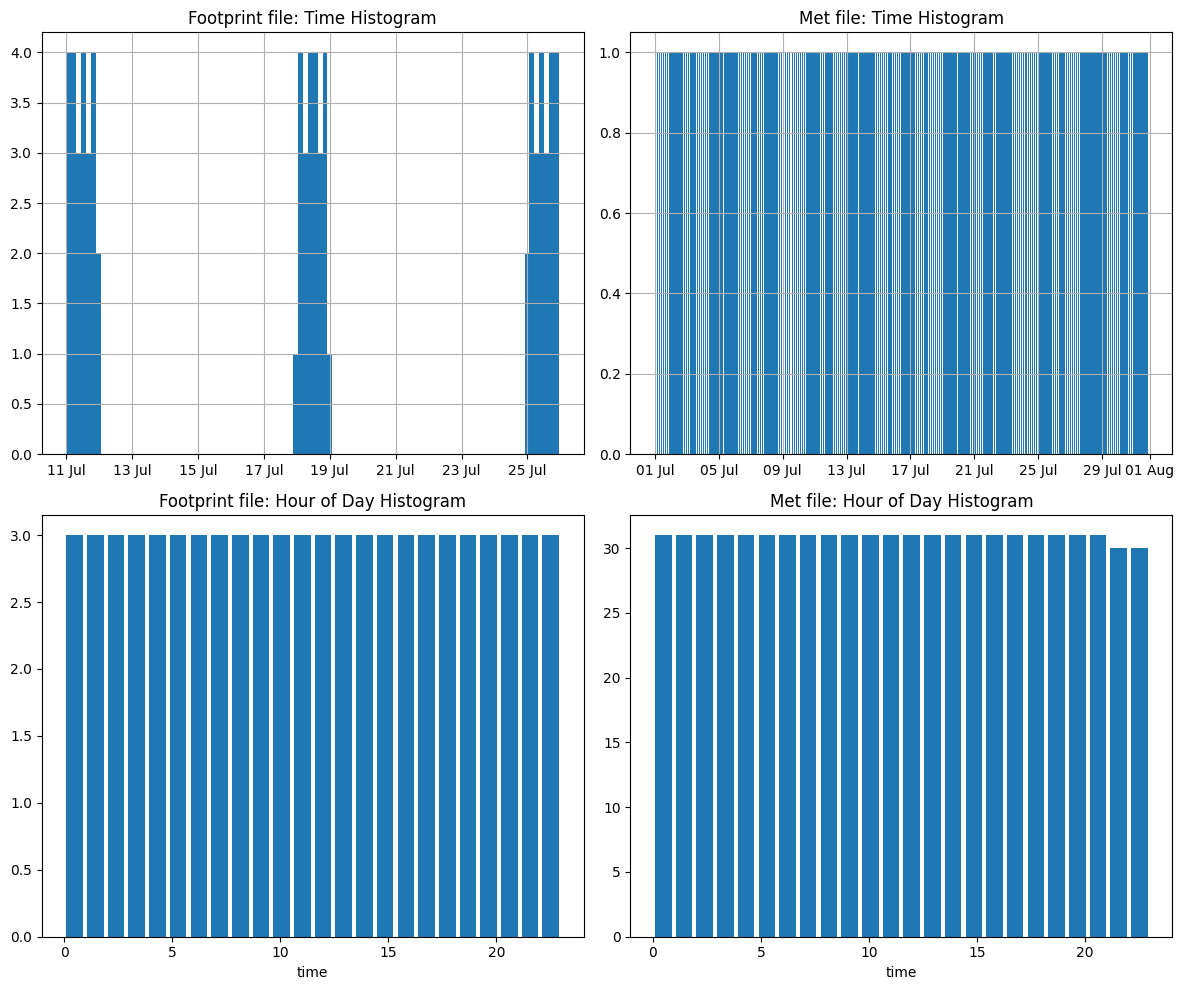

In [43]:
# Visualise fp and met datasets

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
# Example plots using ds and fp_ds time histograms
fp_ds['time'].to_dataframe().hist(column='time', bins=100, ax=axs[0, 0])
axs[0, 0].set_title('Footprint file: Time Histogram')

met_interp['time'].to_dataframe().hist(column='time', bins=1000, ax=axs[0, 1])
axs[0, 1].set_title('Met file: Time Histogram')

fp_ds['time'].dt.hour.plot.hist(bins=24, rwidth=0.8, ax=axs[1, 0])
axs[1, 0].set_title('Footprint file: Hour of Day Histogram')

met_interp['time'].dt.hour.plot.hist(bins=24, rwidth=0.8, ax=axs[1, 1])
axs[1, 1].set_title('Met file: Hour of Day Histogram')

axs[0, 0].xaxis.set_major_formatter(date_formatter)
axs[0, 1].xaxis.set_major_formatter(date_formatter)

plt.tight_layout()
plt.show()

# Several potential options:
1) Choose closest existing met to a fp - no interp
2) Interp to a certain frequency eg 1 hour, then choose closest fp
3) Also consider temporal frequency

Also:
1) Visualise how much met varies over a certain period (eg within 3 hours what is the range of x_winds?)

/user/work/kr21883/.venv/lib64/python3.11/site-packages/xarray/groupers.py:487: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index_grouper = pd.Grouper(
/user/work/kr21883/.venv/lib64/python3.11/site-packages/xarray/groupers.py:487: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index_grouper = pd.Grouper(


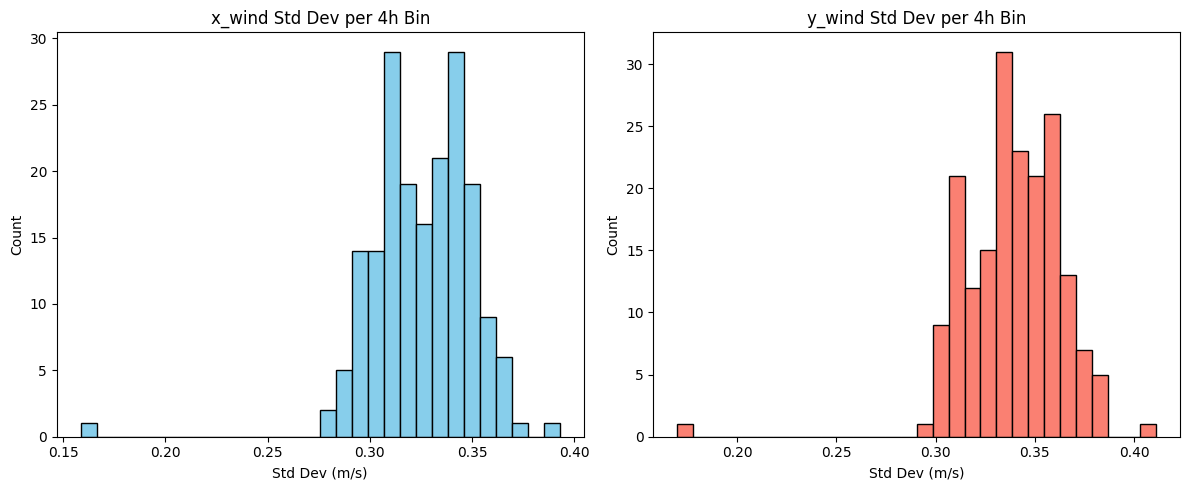

In [59]:
# Set the bin size in hours
bin_hours = 4

# Resample met_interp along the time dimension
# We'll calculate the standard deviation (variation) within each bin for x_wind and y_wind at the lowest model level
level0 = met_interp.model_level_number.values[0]

x_wind_var = met_interp['x_wind'].sel(model_level_number=level0).resample(time=f'{bin_hours}H').std(dim='time')
y_wind_var = met_interp['y_wind'].sel(model_level_number=level0).resample(time=f'{bin_hours}H').std(dim='time')

# For simplicity, take the mean variation over all lat/lon for each bin
x_wind_var_mean = x_wind_var.mean(dim=['latitude', 'longitude']).values
y_wind_var_mean = y_wind_var.mean(dim=['latitude', 'longitude']).values

# Plot histograms of the variations
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].hist(x_wind_var_mean, bins=30, color='skyblue', edgecolor='k')
axs[0].set_title(f'x_wind Std Dev per {bin_hours}h Bin')
axs[0].set_xlabel('Std Dev (m/s)')
axs[0].set_ylabel('Count')

axs[1].hist(y_wind_var_mean, bins=30, color='salmon', edgecolor='k')
axs[1].set_title(f'y_wind Std Dev per {bin_hours}h Bin')
axs[1].set_xlabel('Std Dev (m/s)')
axs[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

/user/work/kr21883/.venv/lib64/python3.11/site-packages/xarray/groupers.py:487: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index_grouper = pd.Grouper(
/user/work/kr21883/.venv/lib64/python3.11/site-packages/xarray/groupers.py:487: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index_grouper = pd.Grouper(
/user/work/kr21883/.venv/lib64/python3.11/site-packages/xarray/groupers.py:487: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index_grouper = pd.Grouper(
/user/work/kr21883/.venv/lib64/python3.11/site-packages/xarray/groupers.py:487: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index_grouper = pd.Grouper(
/user/work/kr21883/.venv/lib64/python3.11/site-packages/xarray/groupers.py:487: FutureWarning: 'H' is deprecated and will be removed in a future ver

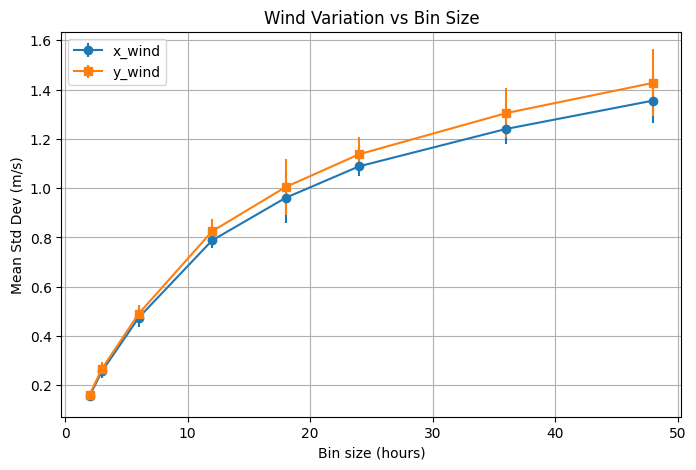

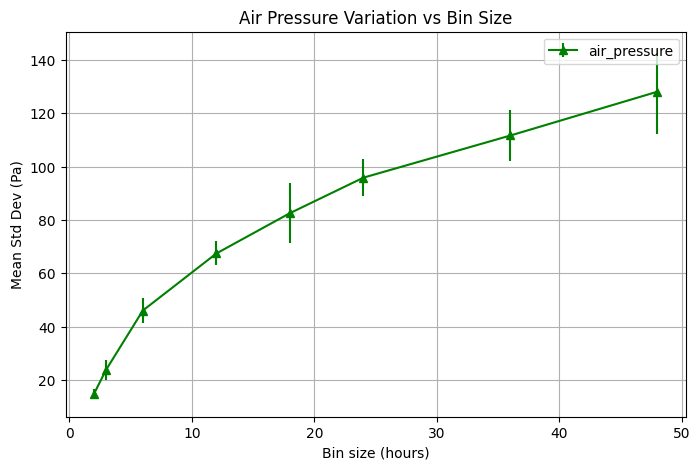

In [ ]:
# Loop over a range of bin_hours and collect mean/std of wind and pressure variations
bin_hours_list = [0.5, 1, 2, 3, 6, 12, 18, 24, 36, 48]
x_wind_means = []
x_wind_stds = []
y_wind_means = []
y_wind_stds = []

level0 = met_interp.model_level_number.values[0]

for bh in bin_hours_list:
    x_var = met_interp['x_wind'].sel(model_level_number=level0).resample(time=f'{bh}h').std(dim='time')
    y_var = met_interp['y_wind'].sel(model_level_number=level0).resample(time=f'{bh}h').std(dim='time')
    x_mean = x_var.mean(dim=['latitude', 'longitude']).values
    y_mean = y_var.mean(dim=['latitude', 'longitude']).values
    x_wind_means.append(np.mean(x_mean))
    x_wind_stds.append(np.std(x_mean))
    y_wind_means.append(np.mean(y_mean))
    y_wind_stds.append(np.std(y_mean))

# Plot summary of variation vs bin_hours
plt.figure(figsize=(8, 5))
plt.errorbar(bin_hours_list, x_wind_means, yerr=x_wind_stds, marker='o', label='x_wind')
plt.errorbar(bin_hours_list, y_wind_means, yerr=y_wind_stds, marker='s', label='y_wind')
plt.xlabel('Bin size (hours)')
plt.ylabel('Mean Std Dev (m/s)')
plt.title('Wind Variation vs Bin Size')
plt.legend()
plt.grid(True)

# Repeat the same analysis for air_pressure at the lowest model level
air_pressure_means = []
air_pressure_stds = []

for bh in bin_hours_list:
    ap_var = met_interp['air_pressure'].sel(model_level_number=level0).resample(time=f'{bh}h').std(dim='time')
    ap_mean = ap_var.mean(dim=['latitude', 'longitude']).values
    air_pressure_means.append(np.mean(ap_mean))
    air_pressure_stds.append(np.std(ap_mean))

plt.figure(figsize=(8, 5))
plt.errorbar(bin_hours_list, air_pressure_means, yerr=air_pressure_stds, marker='^', label='air_pressure', color='green')
plt.xlabel('Bin size (hours)')
plt.ylabel('Mean Std Dev (Pa)')
plt.title('Air Pressure Variation vs Bin Size')
plt.legend()
plt.grid(True)
plt.show()
plt.show()